In [ ]:
import pandas as pd
print("Всё РАБОТАЕТ!")

Всё РАБОТАЕТ!


In [1]:
import numpy as np 
print("Библиотека NumPy тоже готова")

Библиотека NumPy тоже готова


In [2]:
import sqlite3
import pandas as pd
conn=sqlite3.connect('Chinook_Sqlite.sqlite')

query = """
SELECT trackid,name,composer 
FROM track 
limit 10
"""

df = pd.read_sql_query(query,conn)

conn.close

df

,TrackId,Name,Composer
0,1,For Those About To Rock (We Salute You),"Angus Young, Malcolm Young, Brian Johnson"
1,2,Balls to the Wall,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba..."
2,3,Fast As a Shark,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho..."
3,4,Restless and Wild,"F. Baltes, R.A. Smith-Diesel, S. Kaufman, U. D..."
4,5,Princess of the Dawn,Deaffy & R.A. Smith-Diesel
5,6,Put The Finger On You,"Angus Young, Malcolm Young, Brian Johnson"
6,7,Let's Get It Up,"Angus Young, Malcolm Young, Brian Johnson"
7,8,Inject The Venom,"Angus Young, Malcolm Young, Brian Johnson"
8,9,Snowballed,"Angus Young, Malcolm Young, Brian Johnson"
9,10,Evil Walks,"Angus Young, Malcolm Young, Brian Johnson"


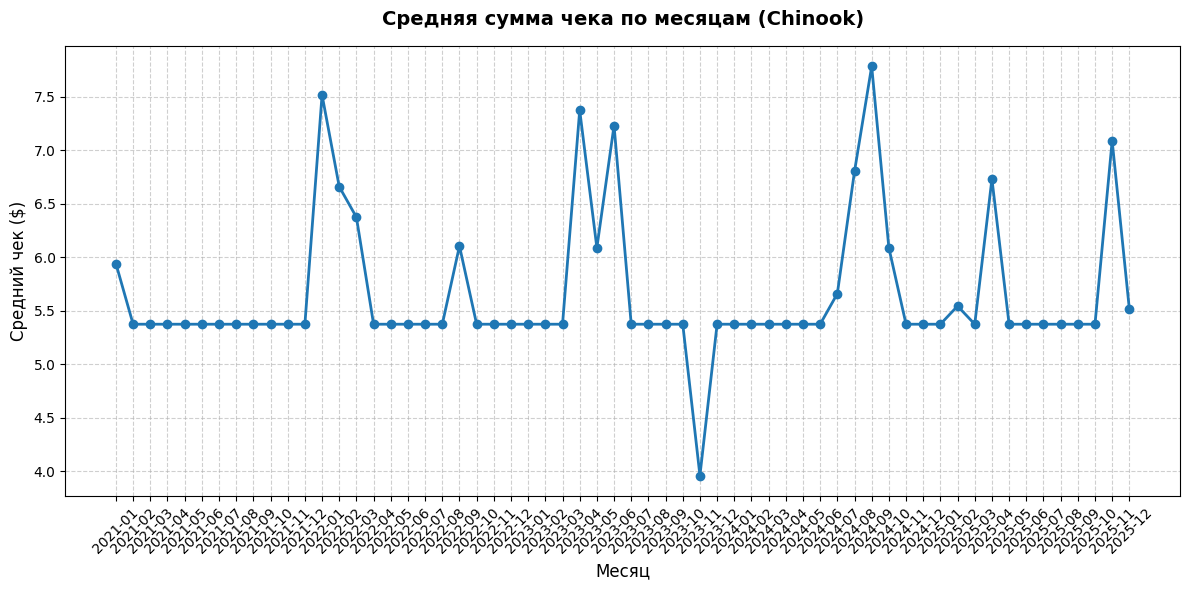

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Подключаемся к базе данных
conn = sqlite3.connect('Chinook_Sqlite.sqlite')

# 2. Пишем SQL-запрос с группировкой по месяцам
# Мы берем дату инвойса, форматируем ее до YYYY-MM и считаем средний чек (Total)
query = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS Month,
    AVG(Total) AS AverageTotal
FROM Invoice
GROUP BY Month
ORDER BY Month;
"""

# 3. Выгружаем данные в Pandas DataFrame
df_sales = pd.read_sql_query(query, conn)
conn.close()

# 4. Строим красивый график
plt.figure(figsize=(12, 6))
plt.plot(df_sales['Month'], df_sales['AverageTotal'], marker='o', color='#1f77b4', linewidth=2)

# Оформление
plt.title('Средняя сумма чека по месяцам (Chinook)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Средний чек ($)', fontsize=12)
plt.xticks(rotation=45) # Наклоняем даты, чтобы они не слипались
plt.grid(True, linestyle='--', alpha=0.6)

# Автоматически подгоняем размеры и выводим
plt.tight_layout()
plt.show()